In [1]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline 


In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
len(words)

32033

In [7]:
# build the voacabulary of characters and mapping to/from integers 
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [9]:
block_size = 3
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y
    
import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

    

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [11]:
# MLP revisited 
n_embd = 10  # dimensionality of character embedding vectors
n_hidden = 200  # number of neurons in the hidden layer of MLP

g = torch.Generator().manual_seed(2147483647) 
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((n_embd * block_size ,n_hidden), generator=g) * 0.2
b1 = torch.randn(n_hidden, generator=g) * 0.01
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # no of parameters
for p in parameters:
    p.requires_grad = True

11897


In [13]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct 
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix] # mini batch

    # forward pass 
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Yb)
    
    
    # backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update 
    #lr = lrs[i]
    lr = 0.01 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 

    # track 
    if i % 10000 == 0:
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
     
    lossi.append(loss.log10().item())
    
    
print(loss.item())


      0/ 200000: 3.3135
  10000/ 200000: 2.2317
  20000/ 200000: 2.3488
  30000/ 200000: 2.5524
  40000/ 200000: 1.9776
  50000/ 200000: 2.5183
  60000/ 200000: 2.4216
  70000/ 200000: 2.0875
  80000/ 200000: 2.2269
  90000/ 200000: 2.1372
 100000/ 200000: 1.9769
 110000/ 200000: 2.1971
 120000/ 200000: 2.0112
 130000/ 200000: 2.4508
 140000/ 200000: 2.3213
 150000/ 200000: 2.2109
 160000/ 200000: 1.8588
 170000/ 200000: 1.7665
 180000/ 200000: 2.0286
 190000/ 200000: 1.8253
2.50563383102417


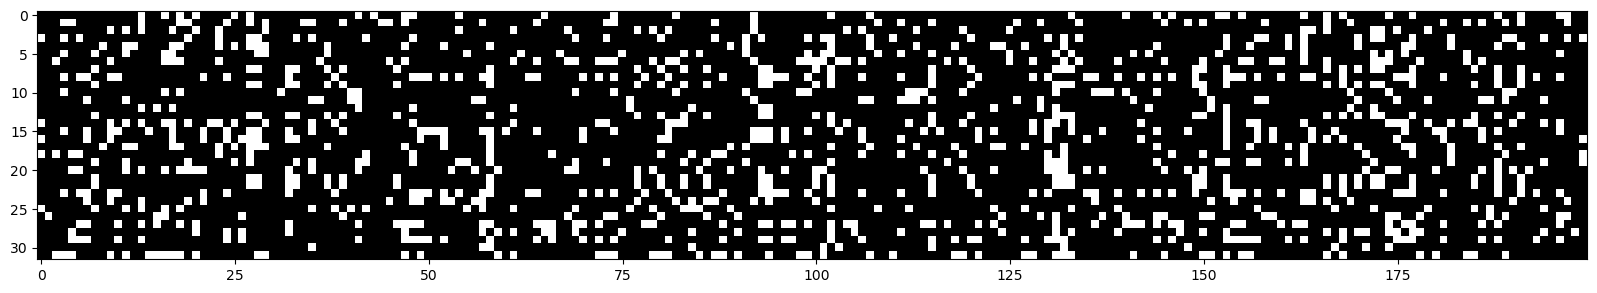

In [15]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99, cmap = 'gray', interpolation='nearest')
plt.show()

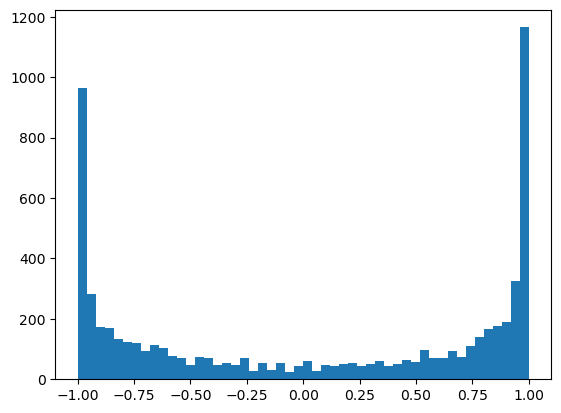

In [17]:
plt.hist(h.view(-1).tolist(), 50);
plt.show()

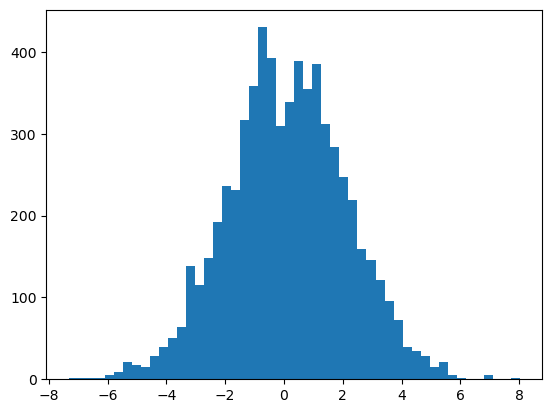

In [19]:
plt.hist(hpreact.view(-1).tolist(), 50);
plt.show()

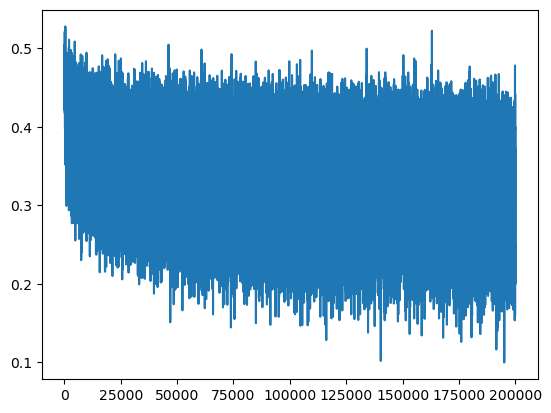

In [21]:
plt.plot(lossi) 
plt.show()

In [23]:
@torch.no_grad() 
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]

    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.0986435413360596
val 2.134600877761841


In [27]:
# loss log 

# fix softmax confidentally wrong:
# train 2.143939733505249
# val 2.1826694011688232

# fix tanh layer too saturated at init:
# train 2.097454071044922
# val 2.1343514919281006

In [29]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      h = torch.tanh(embcat @ W1 + b1)
      
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word
    

carlaiza.
jahmelik.
mili.
taty.
skanden.
jazhutrayvery.
calaeli.
nellara.
chaily.
kaleigh.
ham.
joce.
quinn.
saline.
livabi.
wanell.
dearyxia.
kaellissa.
med.
edi.
